# Summarize mutation filter logs

Import Python modules

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

## Define log paths

In [2]:
# TODO: Update these paths to the new log structure once the pipeline is rerun.
# New paths will be:
#   logs/{segment}/{subtype}/mutation_counts.log         (global trees)
#   logs/{segment}/{subtype}/{host}/mutation_counts.log  (host-specific trees)

ha_subtypes = ["H1", "H3", "H5", "H7", "H9"]
na_subtypes = ["N1", "N2", "N6", "N8", "N9"]
internal_segments = ["PB2", "PB1", "PA", "NP", "MP", "NS"]
host_groups = ["human", "avian"]
log_dir = "../logs/results"

log_paths = {}

# Global trees
for subtype in ha_subtypes:
    log_paths[("HA", subtype, None)] = f"{log_dir}/HA_{subtype}_mutation_counts.log"
for subtype in na_subtypes:
    log_paths[("NA", subtype, None)] = f"{log_dir}/NA_{subtype}_mutation_counts.log"
for seg in internal_segments:
    log_paths[(seg, "all", None)] = f"{log_dir}/{seg}_all_mutation_counts.log"

# Host-specific trees
for subtype in ha_subtypes:
    for host in host_groups:
        log_paths[("HA", subtype, host)] = f"{log_dir}/HA_{subtype}_{host}_mutation_counts.log"
for subtype in na_subtypes:
    for host in host_groups:
        log_paths[("NA", subtype, host)] = f"{log_dir}/NA_{subtype}_{host}_mutation_counts.log"
for seg in internal_segments:
    for host in host_groups:
        log_paths[(seg, "all", host)] = f"{log_dir}/{seg}_all_{host}_mutation_counts.log"

## Parse log files

In [3]:
def parse_log_file(path):
    """Parse a mutation filter log file and return a dict of extracted statistics."""
    result = {}
    with open(path) as f:
        for line in f:
            m = re.search(r"Number of nodes in tree:\s+([\d,]+)", line)
            if m:
                result["n_nodes"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Number of internal nodes in tree:\s+([\d,]+)", line)
            if m:
                result["n_int_nodes"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Total branches examined:\s+([\d,]+)", line)
            if m:
                result["total_branches"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Branches passing filters:\s+([\d,]+)\s+\(([\d.]+)%\)", line)
            if m:
                result["passing_branches"] = int(m.group(1).replace(",", ""))
                result["pct_passing_branches"] = float(m.group(2))

            m = re.search(r"Total mutations \(all branches\):\s+([\d,]+)", line)
            if m:
                result["total_mutations"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Mutations on passing branches:\s+([\d,]+)\s+\(([\d.]+)%\)", line)
            if m:
                result["passing_mutations"] = int(m.group(1).replace(",", ""))
                result["pct_passing_mutations"] = float(m.group(2))

            m = re.search(r"Too many mutations.*?:\s+([\d,]+)", line)
            if m:
                result["filtered_by_too_many"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Zero mutations:\s+([\d,]+)", line)
            if m:
                result["filtered_by_zero"] = int(m.group(1).replace(",", ""))

            m = re.search(r"Duplicate codon targets:\s+([\d,]+)", line)
            if m:
                result["filtered_by_duplicates"] = int(m.group(1).replace(",", ""))

    return result


rows = []
for (segment, subtype, host), path in log_paths.items():
    if not os.path.exists(path):
        print(f"WARNING: log file not found: {path}")
        continue
    stats = parse_log_file(path)
    stats["segment"] = segment
    stats["subtype"] = subtype
    stats["host"] = host if host is not None else "global"
    rows.append(stats)

filter_df = (
    pd.DataFrame(rows)
    .sort_values(["segment", "subtype", "host"])
    .reset_index(drop=True)
)

print(f"Parsed {len(filter_df)} log files")
filter_df.head()

Parsed 48 log files


,n_nodes,n_int_nodes,total_branches,passing_branches,pct_passing_branches,total_mutations,passing_mutations,pct_passing_mutations,filtered_by_too_many,filtered_by_zero,filtered_by_duplicates,segment,subtype,host
0,1543.0,651.0,1542.0,781.0,50.6,11266.0,1447.0,12.8,9799.0,0.0,20.0,HA,H1,avian
1,121887.0,31975.0,121886.0,93058.0,76.3,266299.0,140941.0,52.9,124157.0,0.0,1201.0,HA,H1,global
2,99238.0,22648.0,99237.0,80727.0,81.3,137743.0,117337.0,85.2,19747.0,0.0,659.0,HA,H1,human
3,3906.0,1612.0,3905.0,2088.0,53.5,25311.0,3969.0,15.7,21300.0,0.0,42.0,HA,H3,avian
4,113495.0,27262.0,113494.0,90453.0,79.7,185394.0,132597.0,71.5,52047.0,0.0,750.0,HA,H3,global


## Summary table

In [4]:
display_cols = [
    "segment", "subtype", "host",
    "n_nodes", "n_int_nodes",
    "total_branches", "passing_branches", "pct_passing_branches",
    "total_mutations", "passing_mutations", "pct_passing_mutations",
    "filtered_by_too_many", "filtered_by_zero", "filtered_by_duplicates",
]
filter_df[display_cols]

,segment,subtype,host,n_nodes,n_int_nodes,total_branches,passing_branches,pct_passing_branches,total_mutations,passing_mutations,pct_passing_mutations,filtered_by_too_many,filtered_by_zero,filtered_by_duplicates
0,HA,H1,avian,1543.0,651.0,1542.0,781.0,50.6,11266.0,1447.0,12.8,9799.0,0.0,20.0
1,HA,H1,global,121887.0,31975.0,121886.0,93058.0,76.3,266299.0,140941.0,52.9,124157.0,0.0,1201.0
2,HA,H1,human,99238.0,22648.0,99237.0,80727.0,81.3,137743.0,117337.0,85.2,19747.0,0.0,659.0
3,HA,H3,avian,3906.0,1612.0,3905.0,2088.0,53.5,25311.0,3969.0,15.7,21300.0,0.0,42.0
4,HA,H3,global,113495.0,27262.0,113494.0,90453.0,79.7,185394.0,132597.0,71.5,52047.0,0.0,750.0
5,HA,H3,human,104119.0,23414.0,104118.0,85180.0,81.8,136764.0,122688.0,89.7,13435.0,0.0,641.0
6,HA,H5,avian,27312.0,8339.0,27311.0,20002.0,73.2,68564.0,33751.0,49.2,34511.0,0.0,302.0
7,HA,H5,global,30371.0,9323.0,30370.0,22107.0,72.8,75382.0,37144.0,49.3,37899.0,0.0,339.0
8,HA,H5,human,640.0,258.0,639.0,324.0,50.7,4467.0,661.0,14.8,3795.0,0.0,11.0
9,HA,H7,avian,3638.0,1404.0,3637.0,2201.0,60.5,16782.0,3937.0,23.5,12766.0,0.0,79.0


## Visualizations

/tmp/ipykernel_3177907/4041954285.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bot.set_xticklabels(ax_bot.get_xticklabels(), rotation=45, ha="right")


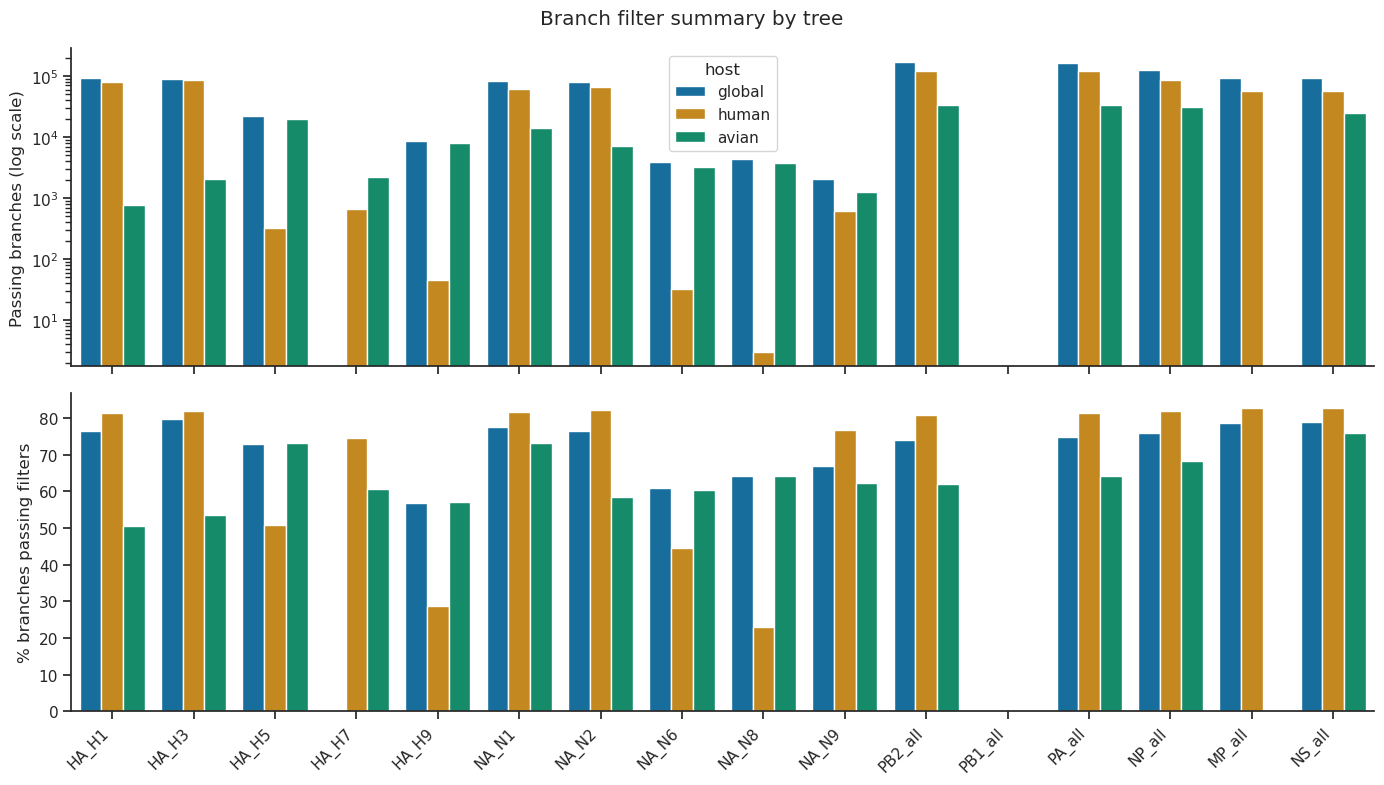

In [5]:

# Figure 1: branch filter summary (top: passing count log scale; bottom: % passing)
seg_order = ["HA", "NA", "PB2", "PB1", "PA", "NP", "MP", "NS"]

plot_df = filter_df.copy()
plot_df["tree_label"] = plot_df["segment"] + "_" + plot_df["subtype"]
plot_df["seg_rank"] = plot_df["segment"].map({s: i for i, s in enumerate(seg_order)})
plot_df = plot_df.sort_values(["seg_rank", "subtype"])
tree_label_order = list(dict.fromkeys(plot_df["tree_label"].tolist()))

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=[14, 8], sharex=True)

sns.barplot(
    data=plot_df,
    x="tree_label", y="passing_branches", hue="host",
    order=tree_label_order, hue_order=["global", "human", "avian"],
    ax=ax_top
)
ax_top.set(yscale="log", ylabel="Passing branches (log scale)", xlabel="")
ax_top.legend(title="host")

sns.barplot(
    data=plot_df,
    x="tree_label", y="pct_passing_branches", hue="host",
    order=tree_label_order, hue_order=["global", "human", "avian"],
    ax=ax_bot
)
ax_bot.get_legend().remove()
ax_bot.set_xticklabels(ax_bot.get_xticklabels(), rotation=45, ha="right")
ax_bot.set(ylabel="% branches passing filters", xlabel="")

fig.suptitle("Branch filter summary by tree")
sns.despine()
plt.tight_layout()
plt.show()


/tmp/ipykernel_3177907/3773947522.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bot.set_xticklabels(ax_bot.get_xticklabels(), rotation=45, ha="right")


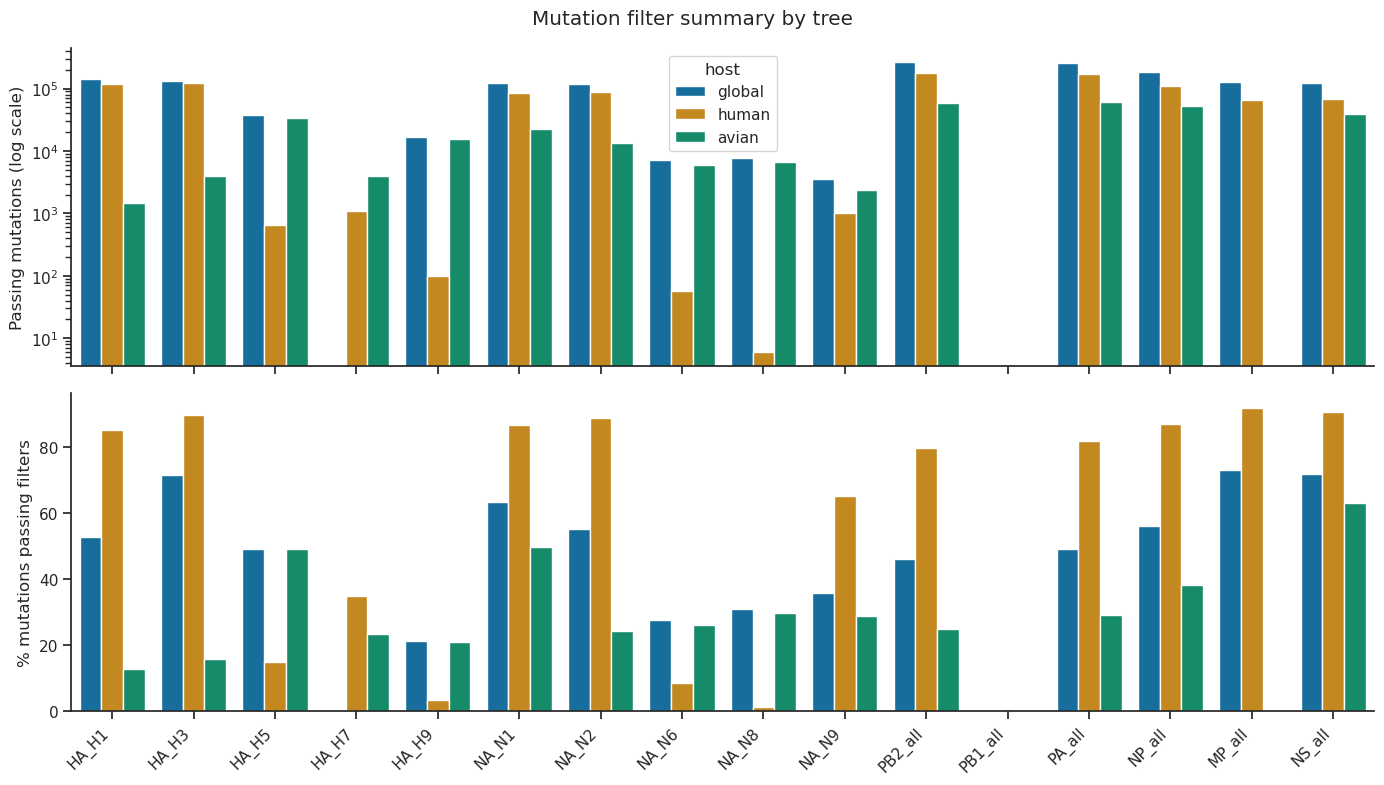

In [6]:

# Figure 2: mutation filter summary (top: passing count log scale; bottom: % passing)
plot_df2 = filter_df.copy()
plot_df2["tree_label"] = plot_df2["segment"] + "_" + plot_df2["subtype"]
plot_df2["seg_rank"] = plot_df2["segment"].map({s: i for i, s in enumerate(seg_order)})
plot_df2 = plot_df2.sort_values(["seg_rank", "subtype"])

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=[14, 8], sharex=True)

sns.barplot(
    data=plot_df2,
    x="tree_label", y="passing_mutations", hue="host",
    order=tree_label_order, hue_order=["global", "human", "avian"],
    ax=ax_top
)
ax_top.set(yscale="log", ylabel="Passing mutations (log scale)", xlabel="")
ax_top.legend(title="host")

sns.barplot(
    data=plot_df2,
    x="tree_label", y="pct_passing_mutations", hue="host",
    order=tree_label_order, hue_order=["global", "human", "avian"],
    ax=ax_bot
)
ax_bot.get_legend().remove()
ax_bot.set_xticklabels(ax_bot.get_xticklabels(), rotation=45, ha="right")
ax_bot.set(ylabel="% mutations passing filters", xlabel="")

fig.suptitle("Mutation filter summary by tree")
sns.despine()
plt.tight_layout()
plt.show()


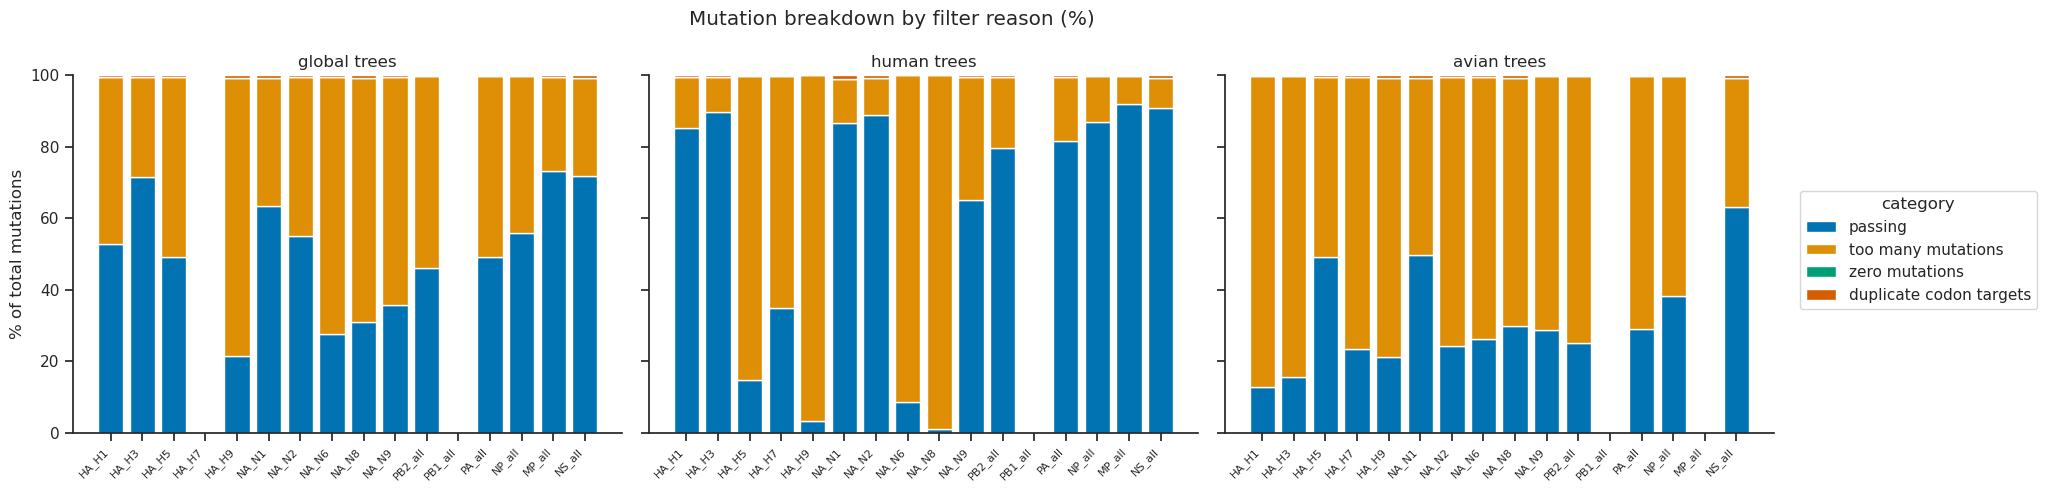

In [7]:

# Figure 3: % mutations by filter reason — stacked bar, faceted by host
plot_df3 = filter_df.copy()
plot_df3["tree_label"] = plot_df3["segment"] + "_" + plot_df3["subtype"]
plot_df3["seg_rank"] = plot_df3["segment"].map({s: i for i, s in enumerate(seg_order)})
plot_df3["pct_passing"] = plot_df3["passing_mutations"] / plot_df3["total_mutations"] * 100
plot_df3["pct_too_many"] = plot_df3["filtered_by_too_many"] / plot_df3["total_mutations"] * 100
plot_df3["pct_zero"] = plot_df3["filtered_by_zero"] / plot_df3["total_mutations"] * 100
plot_df3["pct_duplicates"] = plot_df3["filtered_by_duplicates"] / plot_df3["total_mutations"] * 100
plot_df3 = plot_df3.sort_values(["seg_rank", "subtype"])
tree_label_order3 = list(dict.fromkeys(plot_df3["tree_label"].tolist()))

palette = sns.color_palette("colorblind", 4)
categories = [
    ("pct_passing",    "passing",                palette[0]),
    ("pct_too_many",   "too many mutations",      palette[1]),
    ("pct_zero",       "zero mutations",          palette[2]),
    ("pct_duplicates", "duplicate codon targets", palette[3]),
]

x = np.arange(len(tree_label_order3))
fig, axs = plt.subplots(1, 3, figsize=[18, 5], sharey=True)
for i, (ax, host) in enumerate(zip(axs, ["global", "human", "avian"])):
    host_data = (
        plot_df3[plot_df3["host"] == host]
        .set_index("tree_label")
        .reindex(tree_label_order3)
    )
    bottoms = np.zeros(len(tree_label_order3))
    for col, name, color in categories:
        vals = host_data[col].fillna(0).values
        ax.bar(x, vals, bottom=bottoms, label=(name if i == 0 else None), color=color)
        bottoms += vals
    ax.set_xticks(x)
    ax.set_xticklabels(tree_label_order3, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{host} trees")
    ax.set_xlabel("")

axs[0].set_ylabel("% of total mutations")
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, title="category", bbox_to_anchor=(1.0, 0.5), loc="center left")
fig.suptitle("Mutation breakdown by filter reason (%)")
sns.despine()
plt.tight_layout()
plt.show()
